# Tutorial

We start importing several classes from the `exogaia` package.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.models import BinaryModel
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.priors import NormalPrior, UniformPrior
from exogaia.results import FitResults
from exogaia.sampler import NestedSampler

exogaia

Version: 0.0.2.dev0


In [3]:
g_mag = 10.0

In [4]:
primary_mass = (1.0, 0.1)  # (Msun)
mass_1 = primary_mass[0]  # (Msun)
mass_2 = 0.01  # (Msun)

In [5]:
ra, dec, parallax, pmra, pmdec = 50.0, -50.0, 20.0, 20., -20.
sma, ecc, inc, aop, pan, tau = 3., 0.3, np.radians(45.0), np.radians(60.0), np.radians(90.0), 0.0
model_param = [ra, dec, parallax, pmra, pmdec, sma, ecc, inc, aop, pan, tau, mass_1, mass_2]

In [6]:
epoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release='DR4')


----------------
Epoch astrometry
----------------

Gaia release: DR4
Reference epoch: 2017.5

Primary mass (Msun): 1.00 +/- 0.10


In [7]:
# epoch_astrom.read_file(data_file='../epoch_data/epoch_single.csv')
# epoch_astrom.query_source(2728129004119806464)
# epoch_astrom.gaia_bh3()

In [8]:
epoch_astrom.simulate_data(ra=ra, dec=dec, parallax=parallax, pmra=pmra, pmdec=pmdec,
                           mass_1=mass_1, mass_2=mass_2, sma=sma, ecc=ecc, inc=inc, aop=aop, pan=pan, tau=tau,
                           phot_g_mean_mag=g_mag, sigma_per_ccd=None, csv_out='epoch_binary.csv')


-------------
Simulate data
-------------

AL scan uncertainty (per CCD) = 122.30 uas
AL scan uncertainty (per transit) = 43.24 uas

Stellar parameters:
   - RA (deg) = 50.00
   - Dec (deg) = -50.00
   - Parallax (mas) = 20.00
   - Proper motion in RA (mas/yr) = 20.00
   - Proper motion in Dec (mas/yr) = -20.00
   - G-band magnitude (au) = 10.00

Orbit parameters:
   - Primary mass (Msun) = 1.00
   - Secondary mass (Msun) = 0.01
   - Semi-major axis (au) = 3.00
   - Eccentricity = 0.30
   - Inclination (deg) = 45.00
   - Argument of periastron (deg) = 60.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.00


In [9]:
bin_model = BinaryModel(epoch_astrometry=epoch_astrom)

In [10]:
model = bin_model.calc_model(model_param=model_param)


----------------------
Calculate binary model
----------------------

Stellar parameters:
   - RA (deg) = 50.00
   - Dec (deg) = -50.00
   - Parallax (mas) = 20.00
   - Proper motion in RA (mas/yr) = 20.00
   - Proper motion in Dec (mas/yr) = -20.00

Orbit parameters:
   - Primary mass (Msun) = 1.00
   - Secondary mass (Msun) = 0.01
   - Semi-major axis (au) = 3.00
   - Eccentricity = 0.30
   - Inclination (deg) = 45.00
   - Argument of periastron (deg) = 60.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.00


In [11]:
res = bin_model.calc_residuals(model_param=model_param)


----------------------
Calculate binary model
----------------------

Stellar parameters:
   - RA (deg) = 50.00
   - Dec (deg) = -50.00
   - Parallax (mas) = 20.00
   - Proper motion in RA (mas/yr) = 20.00
   - Proper motion in Dec (mas/yr) = -20.00

Orbit parameters:
   - Primary mass (Msun) = 1.00
   - Secondary mass (Msun) = 0.01
   - Semi-major axis (au) = 3.00
   - Eccentricity = 0.30
   - Inclination (deg) = 45.00
   - Argument of periastron (deg) = 60.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.00

-------------------
Calculate residuals
-------------------

Reduced chi^2 = 1.22
RUWE = 1.10



----------------------
Calculate binary model
----------------------

Stellar parameters:
   - RA (deg) = 50.00
   - Dec (deg) = -50.00
   - Parallax (mas) = 20.00
   - Proper motion in RA (mas/yr) = 20.00
   - Proper motion in Dec (mas/yr) = -20.00

Orbit parameters:
   - Primary mass (Msun) = 1.00
   - Secondary mass (Msun) = 0.01
   - Semi-major axis (au) = 3.00
   - Eccentricity = 0.30
   - Inclination (deg) = 45.00
   - Argument of periastron (deg) = 60.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.00

-------------------
Calculate residuals
-------------------

Reduced chi^2 = 1.22
RUWE = 1.10

----------
Plot orbit
----------



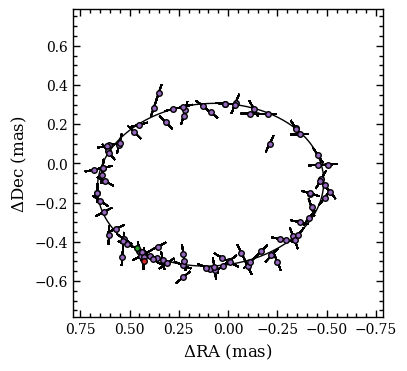

In [12]:
fig = bin_model.plot_orbit(model_param=model_param, output_file='orbit.png')

In [13]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5-parameters)
--------------------------

Reduced chi^2 = 53.665
RUWE = 7.326
Inflation factor = 7.354

Best-fit parameters:
   - RA (deg) = 50.135 +/- 0.050
   - Dec (deg) = -50.179 +/- 0.047
   - Parallax (mas) = 20.044 +/- 0.053
   - mu in RA (mas/yr) = 20.077 +/- 0.032
   - mu in Dec (mas/yr) = -19.930 +/- 0.030


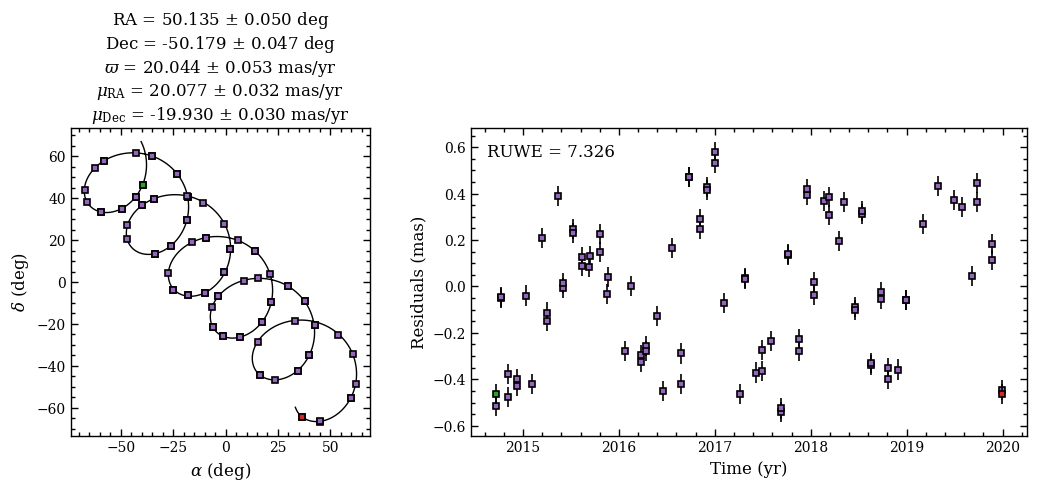

In [14]:
results = leastsq.singl_5param(plot_residuals='res_5param.png')


--------------------------
Binary star (7-parameters)
--------------------------

Reduced chi^2 = 24.897
RUWE = 4.990
Inflation factor = 5.009

Best-fit parameters:
   - RA (deg) = 49.881 +/- 0.046
   - Dec (mas) = -49.957 +/- 0.047
   - Parallax (mas) = 20.014 +/- 0.036
   - mu in RA (mas/yr) = 20.175 +/- 0.025
   - mu in Dec (mas/yr) = -19.968 +/- 0.021
   - dmu/dt in RA (mas/yr^2) = 0.261 +/- 0.031
   - dmu/dt in Dec (mas/yr^2) = -0.196 +/- 0.029


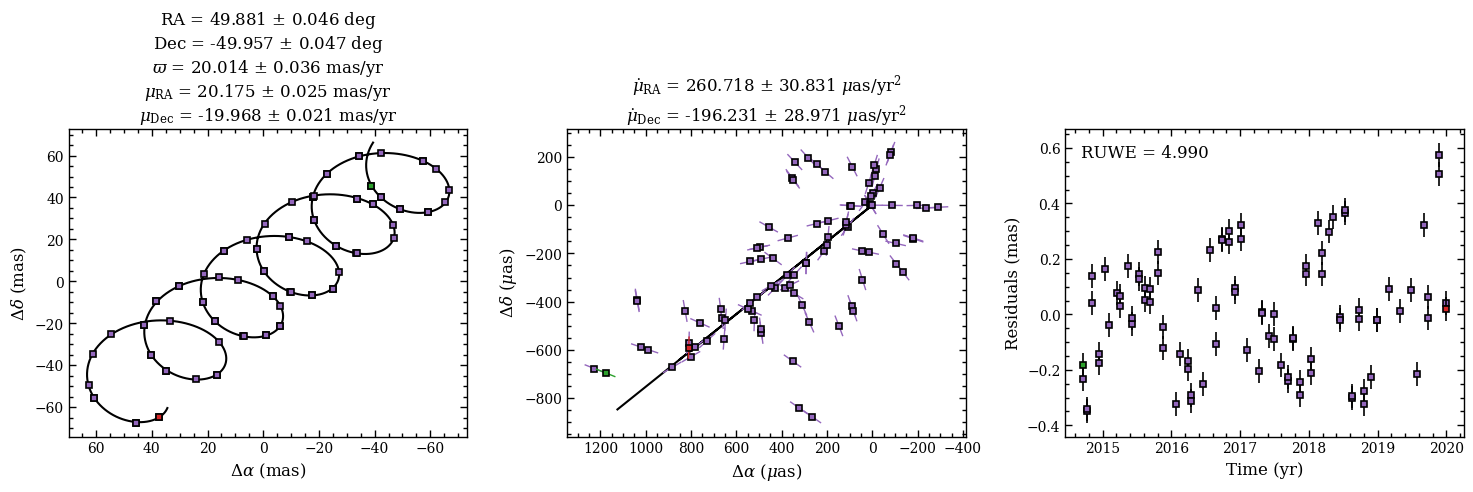

In [15]:
results = leastsq.accel_7param(plot_residuals='res_7param.png')


--------------------------
Binary star (9-parameters)
--------------------------

Reduced chi^2 = 8.761
RUWE = 2.960
Inflation factor = 2.972

Best-fit parameters:
   - RA (deg) = 49.947 +/- 0.028
   - Dec (deg) = -49.936 +/- 0.028
   - Parallax (mas) = 20.007 +/- 0.022
   - mu in RA (mas/yr) = 20.437 +/- 0.031
   - mu in Dec (mas/yr) = -19.772 +/- 0.029
   - dmu/dt in RA (mas/yr^2) = 0.163 +/- 0.021
   - dmu/dt in Dec (mas/yr^2) = -0.218 +/- 0.018
   - d^2mu/d^2t in RA (mas/yr^3) = -0.375 +/- 0.040
   - d^2mu/d^2t in Dec (mas/yr^3) = -0.248 +/- 0.036


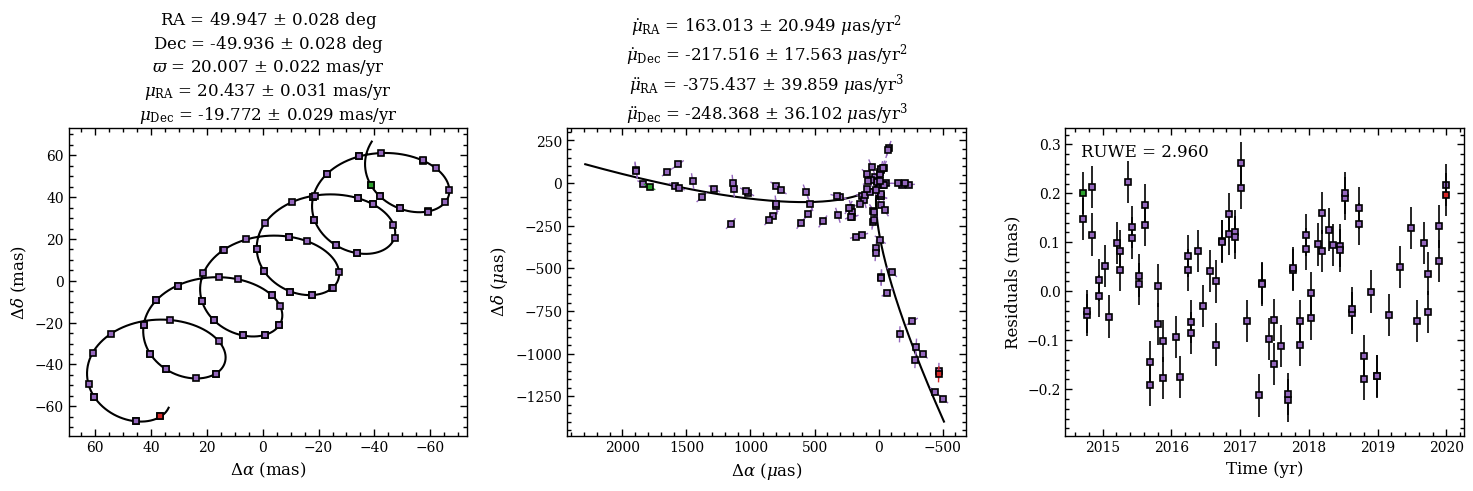

In [16]:
results = leastsq.accel_9param(plot_residuals='res_9param.png')


---------------------
Orbit (12-parameters)
---------------------



  0%|          | 0/125000 [00:00<?, ?it/s]


Best-fit parameters (RUWE = 0.908):
   - RA (deg) = 50.060 +/- 0.007
   - Dec (deg) = -50.018 +/- 0.008
   - Parallax (mas) = 20.012 +/- 0.007
   - mu in RA (mas/yr) = 20.006 +/- 0.006
   - mu in Dec (mas/yr) = -20.002 +/- 0.005
   - Thiele-Innes B = -0.172 +/- 0.010
   - Thiele-Innes G = 0.537 +/- 0.012
   - Thiele-Innes A = 0.394 +/- 0.009
   - Thiele-Innes F = 0.122 +/- 0.012
   - Semi-major axis (au) = 2.924
   - Eccentricity = 0.260
   - Relative time of periastron = 0.03


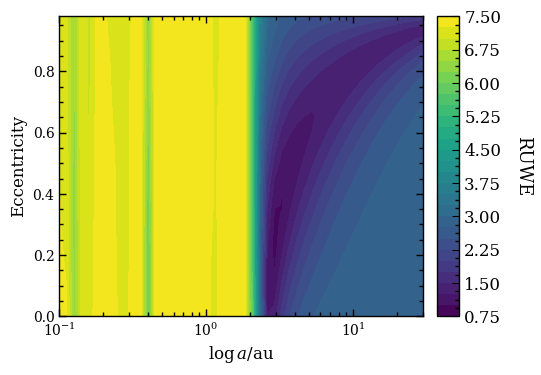

In [17]:
fig = leastsq.orbit_grid(plot_grid='ruwe_orbit.png')

In [18]:
sampler = NestedSampler(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5-parameters)
--------------------------

Reduced chi^2 = 53.665
RUWE = 7.326
Inflation factor = 7.354

Best-fit parameters:
   - RA (deg) = 50.135 +/- 0.050
   - Dec (deg) = -50.179 +/- 0.047
   - Parallax (mas) = 20.044 +/- 0.053
   - mu in RA (mas/yr) = 20.077 +/- 0.032
   - mu in Dec (mas/yr) = -19.930 +/- 0.030

--------------------------
Binary star (7-parameters)
--------------------------

Reduced chi^2 = 24.897
RUWE = 4.990
Inflation factor = 5.009

Best-fit parameters:
   - RA (deg) = 49.881 +/- 0.046
   - Dec (mas) = -49.957 +/- 0.047
   - Parallax (mas) = 20.014 +/- 0.036
   - mu in RA (mas/yr) = 20.175 +/- 0.025
   - mu in Dec (mas/yr) = -19.968 +/- 0.021
   - dmu/dt in RA (mas/yr^2) = 0.261 +/- 0.031
   - dmu/dt in Dec (mas/yr^2) = -0.196 +/- 0.029

--------------------------
Binary star (9-parameters)
--------------------------

Reduced chi^2 = 8.761
RUWE = 2.960
Inflation factor = 2.972

Best-fit parameters:
   - RA (deg) = 49.94

In [19]:
sampler.priors['ra'] = NormalPrior(ra, 0.1)
sampler.priors['dec'] = NormalPrior(dec, 0.1)
sampler.priors['parallax'] = NormalPrior(parallax, 0.1, truncate_zero=True)
sampler.priors['pmra'] = NormalPrior(pmra, 0.1)
sampler.priors['pmdec'] = NormalPrior(pmdec, 0.1)
sampler.priors['sma'] = NormalPrior(sma, 0.1, truncate_zero=True)
sampler.priors['ecc'] = NormalPrior(ecc, 0.1, truncate_zero=True, truncate_one=True)
sampler.priors['inc'] = NormalPrior(inc, 0.1, truncate_zero=True)
sampler.priors['aop'] = NormalPrior(aop, 0.1, truncate_zero=True)
sampler.priors['pan'] = NormalPrior(pan, 0.1, truncate_zero=True)
sampler.priors['tau'] = NormalPrior(tau, 0.1, truncate_zero=True, truncate_one=True)
sampler.priors['mass_2'] = NormalPrior(mass_2, 0.1, truncate_zero=True)

In [ ]:
sampler.run_multinest(
    pickle_file='exogaia.pkl',
    n_live_points=200,
    output_folder='./multinest/',
    resume=False,
    kwargs_multinest={'evidence_tolerance': 3.0, 'verbose': True, 'const_efficiency_mode': True}
)

In [ ]:
results = FitResults(pickle_file='exogaia.pkl')

In [ ]:
truths = [ra, dec, parallax, pmra, pmdec, np.log10(sma), ecc, np.degrees(inc), np.degrees(aop), np.degrees(pan), tau, mass_1, mass_2]
fig = results.plot_posterior(truths=truths, output_file='fit_posterior.png')

In [ ]:
fig = results.plot_residuals(output_file='fit_residuals.png')

In [ ]:
fig = results.plot_orbit(output_file='fit_orbit.png')